## 用梯度下降法实现线性回归

# 构造模拟数据集
  1. np.random.seed(42)：固定随机种子，每次运行噪声一样，结果可复现

  2. np.random.randn() : 生成标准正态分布噪声，*2 放大波动
     np.random.rand() : 随机生成均匀分布的数据

  3. y =真实值+噪声 ：模拟现实带误差的观测数据

# 参数还原
  1. 画图用是的原始(1~10)，训练出来的w只认识标准化[-2,2]的数据，不还原直接F(x) 带入原始 x ，预测值完全离谱

  2. 标准化参数还原原始尺度公式：
 $$\hat y = \frac{w}{\sigma}x + \left(b-\frac{w\mu}{\sigma}\right)$$
 $$w_{原} = \frac{w}{\sigma}$$
 $$b_{原} = b - \frac{w\mu}{\sigma}$$


第1次：w=0.467,b=0.338,差值=157.2014
第2次：w=0.515,b=0.452,差值=154.0731
第3次：w=0.563,b=0.566,差值=151.0071
第4次：w=0.611,b=0.678,差值=148.0020
第5次：w=0.658,b=0.789,差值=145.0568
第6次：w=0.705,b=0.899,差值=142.1701
第7次：w=0.751,b=1.008,差值=139.3410
第8次：w=0.797,b=1.116,差值=136.5681
第9次：w=0.842,b=1.223,差值=133.8504
第10次：w=0.887,b=1.328,差值=131.1867
第11次：w=0.931,b=1.433,差值=128.5761
第12次：w=0.975,b=1.537,差值=126.0175
第13次：w=1.019,b=1.639,差值=123.5097
第14次：w=1.062,b=1.741,差值=121.0519
第15次：w=1.105,b=1.841,差值=118.6429
第16次：w=1.147,b=1.941,差值=116.2819
第17次：w=1.189,b=2.039,差值=113.9679
第18次：w=1.230,b=2.137,差值=111.7000
第19次：w=1.271,b=2.233,差值=109.4771
第20次：w=1.312,b=2.329,差值=107.2985
第21次：w=1.352,b=2.424,差值=105.1633
第22次：w=1.392,b=2.517,差值=103.0706
第23次：w=1.431,b=2.610,差值=101.0195
第24次：w=1.470,b=2.702,差值=99.0092
第25次：w=1.509,b=2.793,差值=97.0389
第26次：w=1.547,b=2.883,差值=95.1078
第27次：w=1.585,b=2.972,差值=93.2152
第28次：w=1.622,b=3.060,差值=91.3602
第29次：w=1.659,b=3.147,差值=89.5421
第30次：w=1.696,b=3.234,差值=87.7602
第31次：w=1.732,b=3.319,差值=86

d:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22122 (\N{CJK UNIFIED IDEOGRAPH-566A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\Li

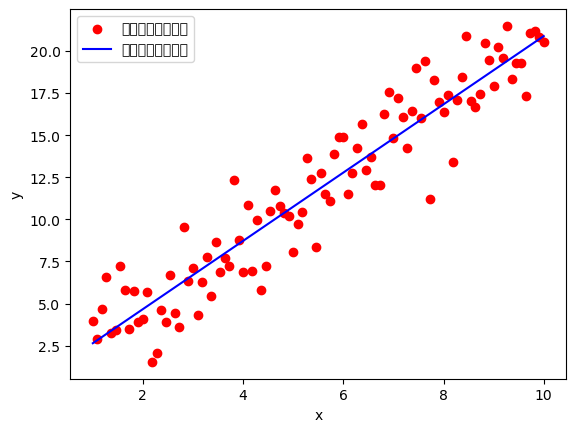

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#原始数据
np.random.seed(42)
x=np.linspace(1,10,100)
f_y=2*x+1
noise=np.random.randn(100)*2
y=f_y+noise
#确定初始theta
w=np.random.rand(1)[0]
b=np.random.rand(1)[0]
#z-score规范化
def standardize(x):
    mu=np.mean(x)
    sigma=np.std(x)
    return (x-mu)/sigma,mu,sigma
x_standardize,x_mu,x_sigma=standardize(x)
#预期函数
def F(x):
    return w*x+b
#设超参数
ETA=1e-2
diff=1
count=0
max_iter=10000
#损失函数
def E(x,y):
    return 0.5*np.sum((F(x)-y)**2)
error=E(x_standardize,y)
while diff>1e-3 and count<max_iter:
    #更新参数
    n=len(x_standardize)
    tmp_w=w-(1/n)*ETA*np.sum((F(x_standardize)-y)*x_standardize)
    tmp_b=b-(1/n)*ETA*np.sum(F(x_standardize)-y)
    w=tmp_w
    b=tmp_b
    #更新误差
    current_error=E(x_standardize,y)
    diff=abs(error-current_error)
    error=current_error
    count+=1
    print("第{}次：w={:.3f},b={:.3f},差值={:.4f}".format(count,w,b,diff))
#生成matplotlib表格
w_original=w/x_sigma
b_original = b - w * x_mu / x_sigma
print("\n===== 训练完成 =====")
print(f"标准化模型参数：w={w:.3f}, b={b:.3f}")
print(f"还原到原始尺度的模型：y = {w_original:.3f}x + {b_original:.3f}")
print(f"真实模型：y = 2x + 1")
# 绘图
plt.scatter(x, y, color='red', label='带噪声的原始数据')
plt.plot(x, w_original * x + b_original, color='blue', label='梯度下降拟合直线')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


    